# Integração Numérica da Distância de Luminosidade pela Métrica de Hogg em Modelos FLRW

Este notebook apresenta a rotina de integração numérica para o cálculo da Distância de Luminosidade ($D_L$) e do Módulo de Distância ($\mu$) baseada na formulação de Hogg para modelos cosmológicos de Friedmann-Lemaître-Robertson-Walker (FLRW).

**Autor:** Victor Moreira Acacio

---

## Fundamentação Teórica e Parâmetros

A evolução da taxa de expansão do universo em função do redshift $z$ é descrita pela função de expansão $E(z)$, que depende dos parâmetros de densidade para a matéria ($\Omega_m$), curvatura ($\Omega_k$) e energia escura ($\Omega_{EE}$), considerando sua equação de estado $w$:

$$E(z) = \sqrt{\Omega_m(1+z)^3 + \Omega_k(1+z)^2 + \Omega_{EE}(1+z)^{3(1+w)}}$$

A partir de $E(z)$, a distância comóvel radial (linha de visada) $D_C$ é obtida através da integração:

$$D_C = \frac{c}{H_0} \int_0^z \frac{dz'}{E(z')}$$

BIBLIOTECAS E DEPENDÊNCIAS

In [1]:
from astropy import constants as const
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.integrate import quad
from pathlib import Path as path
from matplotlib.ticker import AutoMinorLocator

PARAMETERS - Parâmetros modificáveis para a simulação

In [2]:

# * =============================================================================
# * PARÂMETROS INICIAIS
# * =============================================================================

Omega_M = 0.315  # Densidade de matéria [adm.]
Omega_EE = 0.685  # Densidade de energia escura [adm.]
w = -1  # Parâmetro de equação de estado da energia escura [adm.]
z = 10  # Redshift máximo [adm.]


CONSTANTS - Constantes utilizadas dentro do código

In [3]:

# * =============================================================================
# * CONSTANTES FÍSICAS
# * =============================================================================

H0 = 70  # Constante de Hubble [km/s/Mpc]
c = const.c.to("km/s").value  # Velocidade da luz [km/s]

# * =============================================================================
# * CONSTANTES DE SIMULAÇÃO
# * =============================================================================

z_step = 10e-4  # Intervalo entre um ponto e outro nos dados


SYSTEM - Funções de Configuração geral do sistema

In [4]:

# * =============================================================================
# * FUNÇÕES DE ATUALIZAÇÃO DE SISTEMA
# * =============================================================================


def header(titulo, largura=60, **kwargs):
    """Função responsável por criar um output-status em estilo de título de seção."""
    print("\n" + "=" * largura)
    print(f"{titulo.upper():^{largura}}")
    if kwargs:
        info_str = "  |  ".join([f"{k}: {v}" for k, v in kwargs.items()])
        print(f"{info_str:^{largura}}")
    print("-" * largura)


def status(msg):
    """Função responsável por criar um output-status em estilo de status."""
    print(f"\n  > {msg}...")


def param(nome, valor, unidade=""):
    """Função responsável por criar um output-status em estilo de informar parâmetros."""
    unit_str = f" [{unidade}]" if unidade else ""
    print(f"      {nome} = {valor}{unit_str}")


def bar(largura=60):
    """Função responsável por criar um output-status em estilo de barra de divisão."""
    print("\n")
    print("◇" * largura)
    print("\n")


CORE - Núcleo Matemático

In [5]:

# * =============================================================================
# * FUNÇÕES MATEMÁTICAS
# * =============================================================================

# ? -----------------------------------------------------------------------------
# ?         FUNÇÕES FÍSICAS
# ? -----------------------------------------------------------------------------


def q0(Omega_M, Omega_EE, w):
    """Calcula o parâmetro de desaceleração atual (q0) a partir dos parâmetros de densidade de matéria e energia escura."""
    return 0.5 * Omega_M + 0.5 * Omega_EE * (1 + 3 * w)


def dL(Omega_M, Omega_EE, resint, z):
    """Calcula a distância de luminosidade (dL) a partir da distância comóvel transversal (dm) e do redshift (z)."""
    return (1 + z) * dm(Omega_M, Omega_EE, resint)


def approx_dL(Omega_M, Omega_EE, z):
    """Calcula a aproximação de distância de luminosidade (dL) para pequenos redshifts (z) usando o parâmetro de desaceleração (q0)."""
    return (c / H0) * z * (1 + (1 - q0(Omega_M, Omega_EE, w)) * z / 2)


def Omega_K(Omega_M, Omega_EE):
    """Calcula o parâmetro de curvatura (Omega_K) a partir dos parâmetros de densidade de matéria e energia escura."""
    return 1 - (Omega_M + Omega_EE)


def mu(Omega_M, Omega_EE, resint, z):
    """Calcula a magnitude de distância (mu) a partir da distância de luminosidade (dL) e do redshift (z)."""
    return 5 * np.log10(dL(Omega_M, Omega_EE, resint, z)) + 25


def E(z, Omega_M, Omega_EE):
    """Calcula a função de expansão (E) a partir do redshift (z) e dos parâmetros de densidade de matéria e energia escura."""
    return np.sqrt(
        Omega_M * (1 + z) ** 3
        + Omega_EE * (1 + z) ** (3 * (1 + w))
        + Omega_K(Omega_M, Omega_EE) * (1 + z) ** 2
    )


def Sk(Omega_M, Omega_EE, r):
    """Calcula a função de distância comóvel transversal (Sk) a partir do parâmetro de curvatura (k) e da distância comóvel radial (r)."""
    Ok = Omega_K(Omega_M, Omega_EE)
    DH = c / H0
    if Ok > 0:
        return (DH / np.sqrt(Ok)) * np.sinh(np.sqrt(Ok) * r / DH)
    elif Ok < 0:
        return (DH / np.sqrt(-Ok)) * np.sin(np.sqrt(-Ok) * r / DH)
    else:
        return r


def dm(Omega_M, Omega_EE, resint):
    """Calcula a distância comóvel transversal (dm) a partir do parâmetro de curvatura (k) e da distância comóvel radial (dC)."""
    return Sk(Omega_M, Omega_EE, dC(resint))


def dC(resint):
    """Calcula o valor de distância comóvel radial (dC) a partir do resultado da integração dda função integral."""
    return (c / H0) * resint


def k(Omega_M, Omega_EE):
    """Determina o parâmetro de curvatura com base no valor do Parâmetro de Densidade de Curvatura (Omega_k)"""
    Ok = Omega_K(Omega_M, Omega_EE)
    if Ok > 0:
        return -1
    elif Ok < 0:
        return +1
    else:
        return 0


# ? -----------------------------------------------------------------------------
# ?         FUNÇÕES SISTEMÁTICAS DE CÁLCULO
# ? -----------------------------------------------------------------------------


def integral(z, Omega_M, Omega_EE):
    """Formaliza a quantidade a ser integrada para o cálculo da distância comóvel radial (dC) a partir do redshift (z) e dos parâmetros de densidade de matéria e energia escura."""
    return 1 / E(z, Omega_M, Omega_EE)


def UniType(Omega_k):
    """Determina o tipo de universo estudado baseado no valor do Parâmetro de Densidade de Curvatura(Omega_k)"""
    if Omega_k > 0:
        return "Universo Aberto"
    elif Omega_k < 0:
        return "Universo Fechado"
    else:
        return "Universo Plano"


PLOT - Relações de plotagem

In [6]:

# * =============================================================================
# * FUNÇÕES DE CRIAÇÃO DE GRÁFICOS
# * =============================================================================


def plot(
    save, x, y, save_name="", titulo_x="X", titulo_y="Y", tam_fonte=14, espessura=2.5
):
    """Função responsável por plotar gráficos com o estilo padrão LaTeX/Científico."""
    plt.rcParams.update(
        {
            "font.family": "serif",
            "mathtext.fontset": "dejavuserif",
            "axes.labelsize": tam_fonte,
            "font.size": tam_fonte,
            "xtick.labelsize": tam_fonte - 2,
            "ytick.labelsize": tam_fonte - 2,
            "axes.linewidth": 1.2,
        }
    )
    fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
    ax.plot(x, y, linewidth=espessura, color="black", linestyle="-")
    ax.set_title("", fontsize=tam_fonte + 2, pad=15)
    ax.set_xlabel(titulo_x, labelpad=8)
    ax.set_ylabel(titulo_y, labelpad=8)
    ax.tick_params(
        which="major", direction="in", length=6, width=1.2, top=True, right=True
    )
    ax.tick_params(
        which="minor", direction="in", length=3, width=1.0, top=True, right=True
    )
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
    ax.grid(False)
    plt.tight_layout()
    if save == True:
        folderData = path("figures")
        folderData.mkdir(parents=True, exist_ok=True)
        plt.savefig(
            folderData / f"{save_name.replace(' ', '')}.pdf",
            bbox_inches="tight",
            dpi=600,
            facecolor="white",
            transparent=False,
        )
    plt.show()


def ppplot(
    save,
    x1,
    y1,
    x2,
    y2,
    x3,
    y3,
    label1="Modelo1",
    label2="Modelo2",
    label3="Modelo3",
    save_name="",
    titulo_x="X",
    titulo_y="Y",
    tam_fonte=14,
    espessura=2.5,
):
    """Função responsável por plotar gráficos sobrepostos com o estilo padrão LaTeX/Científico."""
    plt.rcParams.update(
        {
            "font.family": "serif",
            "mathtext.fontset": "dejavuserif",
            "axes.labelsize": tam_fonte,
            "font.size": tam_fonte,
            "xtick.labelsize": tam_fonte - 2,
            "ytick.labelsize": tam_fonte - 2,
            "axes.linewidth": 1.2,
        }
    )
    fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
    ax.plot(x1, y1, linewidth=espessura, color="black", linestyle="-", label=label1)
    ax.plot(x2, y2, linewidth=espessura, color="black", linestyle="--", label=label2)
    ax.plot(x3, y3, linewidth=espessura, color="black", linestyle=":", label=label3)
    ax.set_title("", fontsize=tam_fonte + 2, pad=15)
    ax.set_xlabel(titulo_x, labelpad=8)
    ax.set_ylabel(titulo_y, labelpad=8)
    ax.tick_params(
        which="major", direction="in", length=6, width=1.2, top=True, right=True
    )
    ax.tick_params(
        which="minor", direction="in", length=3, width=1.0, top=True, right=True
    )
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
    ax.grid(False)
    ax.legend(
        fontsize=tam_fonte - 2,
        frameon=False,
        fancybox=False,
        shadow=False,
        edgecolor="black",
        loc="best",
    )
    plt.tight_layout()
    if save == True:
        folderData = path("figures")
        folderData.mkdir(parents=True, exist_ok=True)
        plt.savefig(
            folderData / f"{save_name.replace(' ','')}.pdf",
            bbox_inches="tight",
            dpi=600,
            facecolor="white",
            transparent=False,
        )
    plt.show()


SAVES E LOAD - Relações de salvamento e leitura de arquivos na máquina

In [7]:

# * =============================================================================
# * FUNÇÕES DE SALVAMENTO
# * =============================================================================


def save_data(
    nome_arquivo="data",
    decimais=10,
    vecX=[],
    vecY=[],
    description="",
    dominio_inferior=0.0,
    dominio_superior=0.0,
    x_grand="",
    x_unit="",
    y_grand="",
    y_unit="",
):
    """Função responsável por salvar um determinado conjunto de dados em um arquivo.txt"""
    data = np.column_stack((vecX, vecY))
    header_text = (
        f"Descripiton: {description}\n"
        f"Domain: {x_grand} in [{dominio_inferior}, {dominio_superior}]\n"
        f"Units: {x_grand} [{x_unit}], {y_grand} [{y_unit}] \n"
        f"{x_grand},{y_grand}"
    )
    folderData = path("data")
    folderData.mkdir(parents=True, exist_ok=True)
    np.savetxt(
        f"{folderData}/{nome_arquivo}.txt",
        data,
        fmt=f"%.{decimais}f",
        delimiter=",",
        header=header_text,
        comments="# ",
    )


# * =============================================================================
# * FUNÇÕES DE CARREGAMENTO
# * =============================================================================


def load_data(caminho_arquivo):
    """
    Lê um arquivo .txt formatado com cabeçalhos '#' e separado por vírgulas.
    Retorna dois vetores (vetor X e vetor Y).
    """
    try:
        vetor_x, vetor_y = np.loadtxt(caminho_arquivo, delimiter=",", unpack=True)
        return vetor_x, vetor_y
    except FileNotFoundError:  # Except apra caso o caminho não seja encontrado
        print(f"Erro: O arquivo '{caminho_arquivo}' não foi encontrado.")
        return [], []
    except Exception as e:  # Except para outros casos de falha
        print(f"Erro ao ler o arquivo: {e}")
        return [], []


MAIN - Simula o modelo FLRW

In [8]:

# * =============================================================================
# * ROTINA PRINCIPAL
# * =============================================================================

# ? -----------------------------------------------------------------------------
# ?         FUNÇÃO MAIN
# ? -----------------------------------------------------------------------------


def main(Omega_M, Omega_EE, w, z, z_step, type="custom"):
    header(
        "iniciando HoggCosmoMeasures...", Omega_M=Omega_M, Omega_EE=Omega_EE, w=w, z=z
    )
    try:
        IntANDError = quad(integral, 0, z, args=(Omega_M, Omega_EE))
        resint = IntANDError[0]
        ERRORresint = IntANDError[1]
        status("Processo de integração numérica finalizado com sucesso!")
        param("Integração Numérica", resint, "Mpc")
        param("Erro Estimado", ERRORresint, "Mpc")
    except Exception as e:
        status(f"Processo de integração numérica falhou! Erro: {e}")
    status("Iniciando cálculo de parâmetros do universo")
    param("Tipo de universo", UniType(Omega_K(Omega_M, Omega_EE)))
    param("Constante de curvatura espacial (k)", k(Omega_M, Omega_EE))
    param("Parâmetro derivado de curvatura (Omega_K)", Omega_K(Omega_M, Omega_EE))
    param("Distância comóvel radial (dC)", dC(resint), "Mpc")
    param("Parâmetro de desaceleração (q0)", q0(Omega_M, Omega_EE, w))
    status("Iniciando exportação de dados")
    try:
        DLvectorX = []
        DLvectorY = []
        MUvectorX = []
        MUvectorY = []
        DLAPvectorX = []
        DLAPvectorY = []
        DIFvectorX = []
        DIFvectorY = []
        iter = 0
        for i in np.arange(float(z_step), float(z) + float(z_step), float(z_step)):
            resint = quad(integral, 0, i, args=(Omega_M, Omega_EE))[0]
            DLvectorX.append(i)
            DLvectorY.append(dL(Omega_M, Omega_EE, resint, i))
            MUvectorX.append(i)
            MUvectorY.append(mu(Omega_M, Omega_EE, resint, i))
            DLAPvectorX.append(i)
            DLAPvectorY.append(approx_dL(Omega_M, Omega_EE, i))
        for y in DLvectorY:
            DIFvectorY.append(y - DLAPvectorY[iter])
            iter = iter + 1
        DIFvectorX = DLvectorX
        if type == "custom":
            save_data(
                f"DLdados",
                10,
                DLvectorX,
                DLvectorY,
                "Distribuicao de Distancia de Luminosidade",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"MUdados",
                10,
                MUvectorX,
                MUvectorY,
                "Distribuicao de Modulo de Distancia",
                0,
                10,
                "z",
                "adm.",
                "mu",
                "mag",
            )
            save_data(
                f"DLAPdados",
                10,
                DLAPvectorX,
                DLAPvectorY,
                "Distribuicao de Distancia de Luminosidade Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"DIFdados",
                10,
                DIFvectorX,
                DIFvectorY,
                "Analise de Erro na Distribuicao de Distancia de Luminosidade exata e Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
        elif type == "M":
            save_data(
                f"DLdadosM",
                10,
                DLvectorX,
                DLvectorY,
                "Distribuicao de Distancia de Luminosidade",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"MUdadosM",
                10,
                MUvectorX,
                MUvectorY,
                "Distribuicao de Modulo de Distancia",
                0,
                10,
                "z",
                "adm.",
                "mu",
                "mag",
            )
            save_data(
                f"DLAPdadosM",
                10,
                DLAPvectorX,
                DLAPvectorY,
                "Distribuicao de Distancia de Luminosidade Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"DIFdadosM",
                10,
                DIFvectorX,
                DIFvectorY,
                "Analise de Erro na Distribuicao de Distancia de Luminosidade exata e Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
        elif type == "EE":
            save_data(
                f"DLdadosEE",
                10,
                DLvectorX,
                DLvectorY,
                "Distribuicao de Distancia de Luminosidade",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"MUdadosEE",
                10,
                MUvectorX,
                MUvectorY,
                "Distribuicao de Modulo de Distancia",
                0,
                10,
                "z",
                "adm.",
                "mu",
                "mag",
            )
            save_data(
                f"DLAPdadosEE",
                10,
                DLAPvectorX,
                DLAPvectorY,
                "Distribuicao de Distancia de Luminosidade Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"DIFdadosEE",
                10,
                DIFvectorX,
                DIFvectorY,
                "Analise de Erro na Distribuicao de Distancia de Luminosidade exata e Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
        status("Exportação de dados concluida com sucesso!")
        status("Rotina principal finalizada!")
    except Exception as e:
        status(f"Falha no processo de salvamento! Erro: {e}")


# ? -----------------------------------------------------------------------------
# ?         MAIN GUARD
# ? -----------------------------------------------------------------------------


if __name__ == "__main__":
    main(Omega_M, Omega_EE, w, z, z_step, type="custom")



               INICIANDO HOGGCOSMOMEASURES...               
   Omega_M: 0.315  |  Omega_EE: 0.685  |  w: -1  |  z: 10   
------------------------------------------------------------

  > Processo de integração numérica finalizado com sucesso!...
      Integração Numérica = 2.1658774268377683 [Mpc]
      Erro Estimado = 1.867051910489849e-12 [Mpc]

  > Iniciando cálculo de parâmetros do universo...
      Tipo de universo = Universo Plano
      Constante de curvatura espacial (k) = 0
      Parâmetro derivado de curvatura (Omega_K) = 0.0
      Distância comóvel radial (dC) = 9275.910250262996 [Mpc]
      Parâmetro de desaceleração (q0) = -0.5275000000000001

  > Iniciando exportação de dados...

  > Exportação de dados concluida com sucesso!...

  > Rotina principal finalizada!...


BASIC_PLOTS - Plots do Universo simulado customizado em parâmetros


                  INICIANDO BASIC PLOTS...                  
------------------------------------------------------------


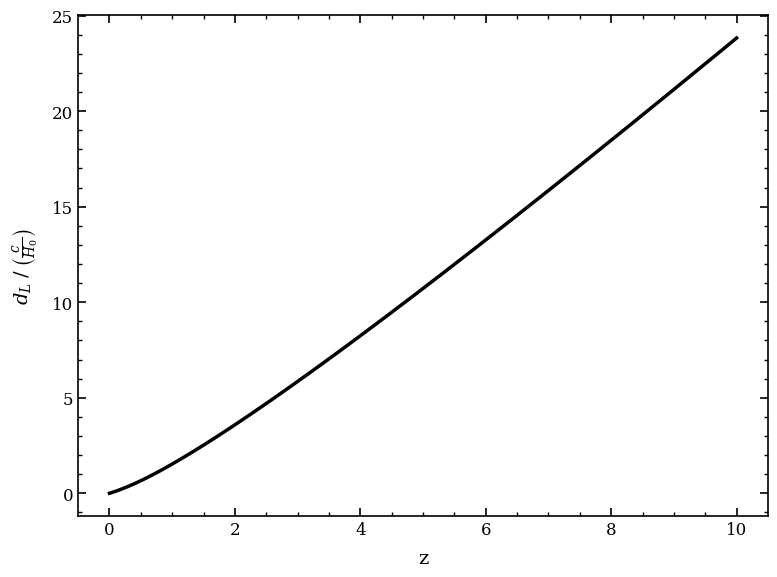

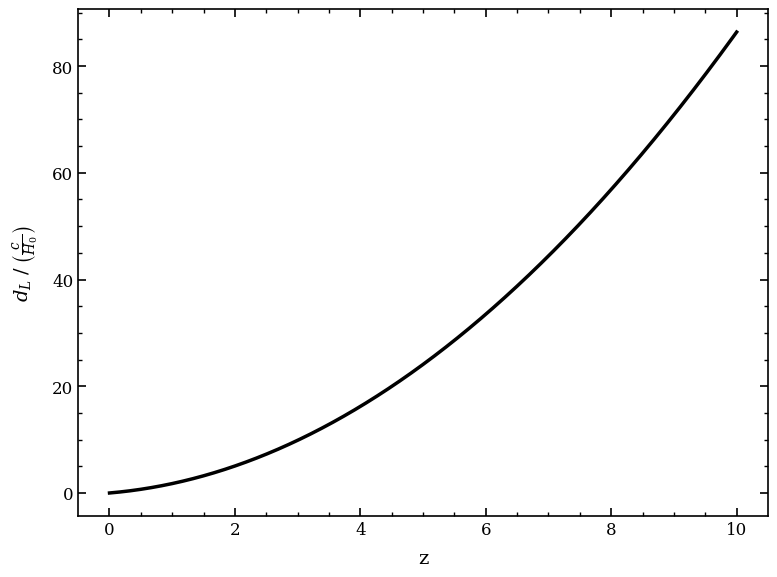

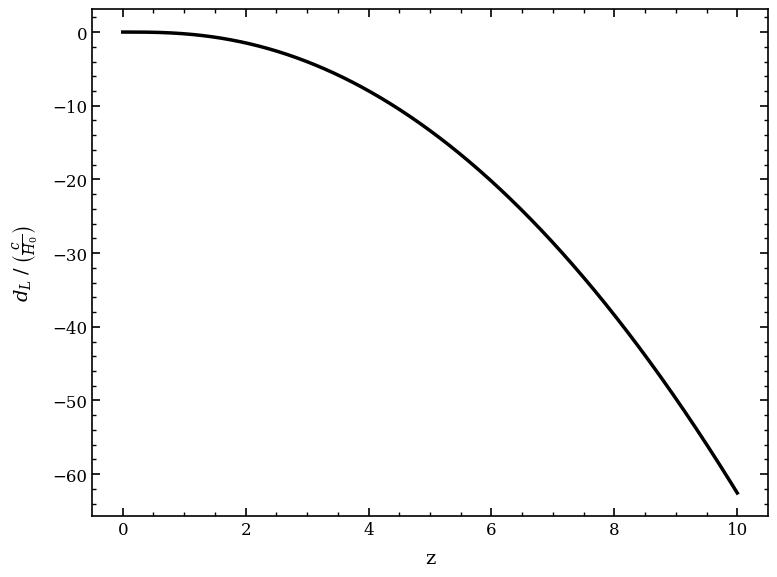

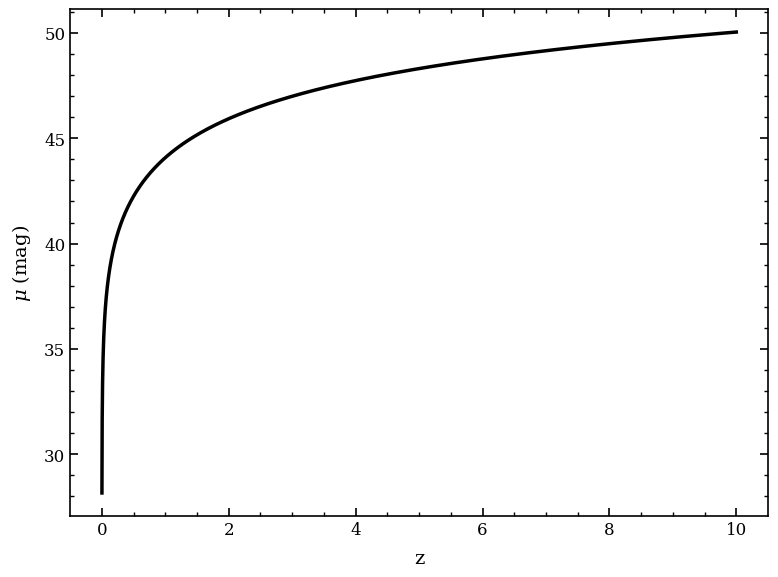


  > Criação e salvamento dos gráficos concluida com sucesso!...

  > Rotina de criação de gráficos finalizada...


In [9]:

# * =============================================================================
# * ROTINA PRINCIPAL
# * =============================================================================

header("Iniciando basic plots...")

try:
    DLvectorX = load_data(f"data/DLdados.txt")[0]
    DLAPvectorX = load_data(f"data/DLAPdados.txt")[0]
    DIFvectorX = load_data(f"data/DIFdados.txt")[0]
    MUvectorX = load_data(f"data/MUdados.txt")[0]
    DLvectorY = load_data(f"data/DLdados.txt")[1]
    DLAPvectorY = load_data(f"data/DLAPdados.txt")[1]
    DIFvectorY = load_data(f"data/DIFdados.txt")[1]
    MUvectorY = load_data(f"data/MUdados.txt")[1]
    plot(
        True,
        DLvectorX,
        DLvectorY / (c / H0),
        f"Curva de Distância de Luminosidade",
        "z",
        r"$d_L \; /\; \left(\frac{c}{H_0}\right)$",
    )
    plot(
        True,
        DLAPvectorX,
        DLAPvectorY / (c / H0),
        f"Curva de Distância de Luminosidade Aproximada",
        "z",
        r"$d_L \; /\; \left(\frac{c}{H_0}\right)$",
    )
    plot(
        True,
        DIFvectorX,
        DIFvectorY / (c / H0),
        f"Anlálise de Erro Aproximação vs. Exato",
        "z",
        r"$d_L \; /\; \left(\frac{c}{H_0}\right)$",
    )
    plot(
        True,
        MUvectorX,
        MUvectorY,
        f"Curva de Módulo de Distância",
        "z",
        r"$\mu$ (mag)",
    )
    status("Criação e salvamento dos gráficos concluida com sucesso!")
    status("Rotina de criação de gráficos finalizada")
except Exception as e:
    status(f"Falha no processo de plotagem dos gráficos! Erro: {e}")


COMPARISON_PLOT - Plots de comparação do universo customizado com universos característicos


                INICIANDO COMPARISON PLOT...                
------------------------------------------------------------

  > Iniciando 1a análise...

               INICIANDO HOGGCOSMOMEASURES...               
   Omega_M: 0.315  |  Omega_EE: 0.685  |  w: -1  |  z: 10   
------------------------------------------------------------

  > Processo de integração numérica finalizado com sucesso!...
      Integração Numérica = 2.1658774268377683 [Mpc]
      Erro Estimado = 1.867051910489849e-12 [Mpc]

  > Iniciando cálculo de parâmetros do universo...
      Tipo de universo = Universo Plano
      Constante de curvatura espacial (k) = 0
      Parâmetro derivado de curvatura (Omega_K) = 0.0
      Distância comóvel radial (dC) = 9275.910250262996 [Mpc]
      Parâmetro de desaceleração (q0) = -0.5275000000000001

  > Iniciando exportação de dados...

  > Exportação de dados concluida com sucesso!...

  > Rotina principal finalizada!...


◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇

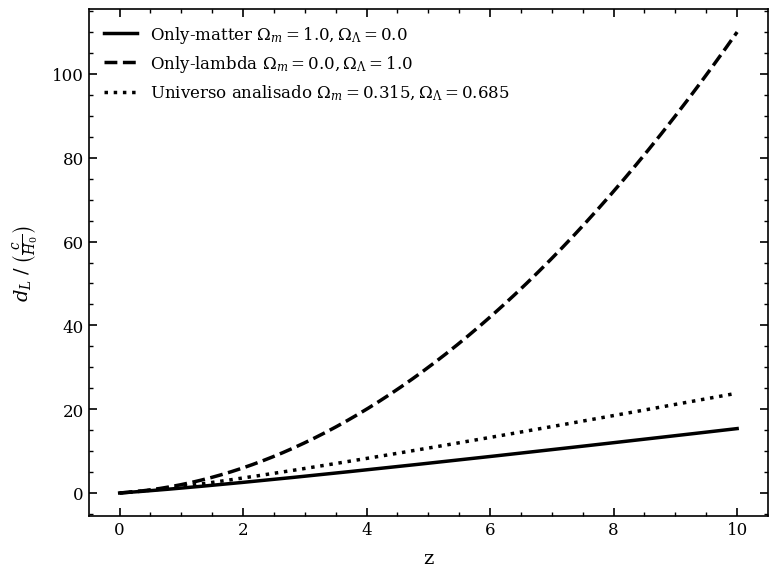


  > Gráficos de Distância de Luminosidade criados com sucesso!...


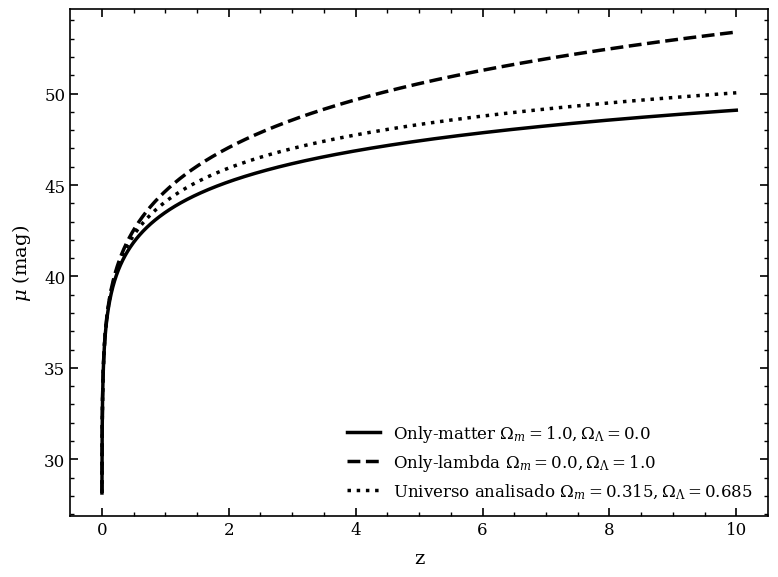


  > Gráficos de Módulo de Distância criados com sucesso!...

  > Rotina de criação de gráficos sobrepostos finalizada!...


In [10]:

# * =============================================================================
# * ROTINA PRINCIPAL
# * =============================================================================

try:
    header("Iniciando comparison plot...")
    status("Iniciando 1a análise")
    main(Omega_M, Omega_EE, w, z, z_step, "custom")
    bar()
    status("Iniciando 2a análise")
    main(1, 0, -1, z, z_step, "M")
    bar()
    status("Iniciando 3a análise")
    main(0, 1, -1, z, z_step, "EE")
    bar()
    status("Todas as análises terminadas!")
except Exception as e:
    status(f"Um erro foi encontrado ao tentar executar a rotina principal. Erro: {e}")

try:
    status("Iniciando criação de gráficos de Distância de Luminosidade")
    dadosM = "DLdadosM.txt"
    dadosEE = "DLdadosEE.txt"
    dadosMEE = f"DLdados.txt"
    x1 = load_data(f"data/DLdadosM.txt")[0]
    x2 = load_data(f"data/DLdadosEE.txt")[0]
    x3 = load_data(f"data/DLdados.txt")[0]
    y1 = load_data(f"data/DLdadosM.txt")[1] / (c / H0)
    y2 = load_data(f"data/DLdadosEE.txt")[1] / (c / H0)
    y3 = load_data(f"data/DLdados.txt")[1] / (c / H0)
    ppplot(
        True,
        x1,
        y1,
        x2,
        y2,
        x3,
        y3,
        r"Only-matter $\Omega_m=1.0, \Omega_\Lambda=0.0$",
        r"Only-lambda $\Omega_m=0.0, \Omega_\Lambda=1.0$",
        rf"Universo analisado $\Omega_m={Omega_M}, \Omega_\Lambda={Omega_EE}$",
        "Comparação de Distâncias de Luminosidade",
        "z",
        r"$d_L \; /\; \left(\frac{c}{H_0}\right)$",
        espessura=2.5,
    )
    status("Gráficos de Distância de Luminosidade criados com sucesso!")
except Exception as e:
    status(
        f"Um erro foi encontrado ao tentar fazer a sobreposição dos gráficos de Distância de luminosidade. Erro: {e}"
    )

try:
    dadosM = "MUdadosM.txt"
    dadosEE = "MUdadosEE.txt"
    dadosMEE = f"MUdados.txt"
    x1 = load_data(f"data/MUdadosM.txt")[0]
    x2 = load_data(f"data/MUdadosEE.txt")[0]
    x3 = load_data(f"data/MUdados.txt")[0]
    y1 = load_data(f"data/MUdadosM.txt")[1]
    y2 = load_data(f"data/MUdadosEE.txt")[1]
    y3 = load_data(f"data/MUdados.txt")[1]
    ppplot(
        True,
        x1,
        y1,
        x2,
        y2,
        x3,
        y3,
        r"Only-matter $\Omega_m=1.0, \Omega_\Lambda=0.0$",
        r"Only-lambda $\Omega_m=0.0, \Omega_\Lambda=1.0$",
        rf"Universo analisado $\Omega_m={Omega_M}, \Omega_\Lambda={Omega_EE}$",
        "Comparação de Módulos e Distância",
        "z",
        r"$\mu$ (mag)",
    )
    status("Gráficos de Módulo de Distância criados com sucesso!")
except Exception as e:
    status(
        f"Um erro foi encontrado ao tentar fazer a sobreposição dos gráficos de Módulo de Distância. Erro: {e}"
    )

status("Rotina de criação de gráficos sobrepostos finalizada!")
